# DeiT-Tiny con Fine-Tuning para Clasificación Morfológica de Galaxias
## TFM — Galaxy10 DECaLS
**Autora:** Paula Regalado de León

Este notebook implementa la Solución 3 del TFM: clasificación morfológica de galaxias usando DeiT-Tiny (Data-efficient Image Transformer) preentrenado con fine-tuning sobre el dataset Galaxy10 DECaLS.

**Estructura del notebook:**
1. Configuración del entorno
2. Carga del dataset
3. Exploración y análisis del dataset
4. Preparación y partición de datos
5. Definición del modelo DeiT-Tiny
6. Fase 1: Entrenamiento de la cabeza clasificadora
7. Fase 2: Fine-tuning completo
8. Evaluación sobre el conjunto de prueba
9. Análisis de resultados y matrices de confusión

---
**Orden de clases en este dataset (verificado experimentalmente):**
- Clase 0: Disturbed Galaxies (1.081 imágenes)
- Clase 1: Merging Galaxies (1.853 imágenes)
- Clase 2: Round Smooth Galaxies (2.645 imágenes)
- Clase 3: In-between Round Smooth Galaxies (2.027 imágenes)
- Clase 4: Cigar Shaped Smooth Galaxies (334 imágenes)
- Clase 5: Barred Spiral Galaxies (2.043 imágenes)
- Clase 6: Unbarred Tight Spiral Galaxies (1.829 imágenes)
- Clase 7: Unbarred Loose Spiral Galaxies (2.628 imágenes)
- Clase 8: Edge-on Galaxies without Bulge (1.423 imágenes)
- Clase 9: Edge-on Galaxies with Bulge (1.873 imágenes)

## 1. Configuración del entorno

In [1]:
# Verificar que la GPU está disponible
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️ No se detectó GPU. El entrenamiento será muy lento en CPU.")

PyTorch version: 2.12.0+cu130
GPU disponible: True
GPU: NVIDIA GeForce GTX 1650
VRAM disponible: 4.0 GB


In [2]:
# Instalación de dependencias
# timm es la librería que contiene DeiT-Tiny preentrenado
!pip install timm --quiet
!pip install h5py scikit-learn matplotlib seaborn --quiet
print("✅ Dependencias instaladas")


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Dependencias instaladas



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Importaciones
import os
import random
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import timm  # librería con modelos preentrenados incluyendo DeiT

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

print(f"timm version: {timm.__version__}")
print("✅ Importaciones completadas")

c:\Users\Usuario\Desktop\tfm\venv_tfm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


timm version: 1.0.27
✅ Importaciones completadas


In [4]:
# Configuración de semilla para reproducibilidad
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento: {DEVICE}")

# Hiperparámetros
IMG_SIZE    = 224      # DeiT-Tiny espera imágenes de 224x224
BATCH_SIZE  = 32       # Reducir a 16 si hay error CUDA out of memory
NUM_CLASSES = 10
LR_HEAD     = 1e-3     # Tasa de aprendizaje Fase 1 (solo cabeza)
LR_FINETUNE = 1e-4     # Tasa de aprendizaje Fase 2 (fine-tuning completo)
WEIGHT_DECAY = 1e-4
EPOCHS_HEAD    = 8     # Épocas Fase 1
EPOCHS_FINETUNE = 12   # Épocas Fase 2
PATIENCE    = 5        # Early stopping
NUM_WORKERS = 0        # 0 en Windows para evitar errores de multiprocessing

# Orden de clases verificado experimentalmente en este dataset
CLASS_NAMES = [
    "Disturbed Galaxies",                  # 0 — 1.081 imágenes
    "Merging Galaxies",                    # 1 — 1.853 imágenes
    "Round Smooth Galaxies",               # 2 — 2.645 imágenes
    "In-between Round Smooth Galaxies",    # 3 — 2.027 imágenes
    "Cigar Shaped Smooth Galaxies",        # 4 —   334 imágenes
    "Barred Spiral Galaxies",              # 5 — 2.043 imágenes
    "Unbarred Tight Spiral Galaxies",      # 6 — 1.829 imágenes
    "Unbarred Loose Spiral Galaxies",      # 7 — 2.628 imágenes
    "Edge-on Galaxies without Bulge",      # 8 — 1.423 imágenes
    "Edge-on Galaxies with Bulge"          # 9 — 1.873 imágenes
]

print("✅ Configuración lista")

Dispositivo de entrenamiento: cuda
✅ Configuración lista


## 2. Carga del dataset

In [5]:
# El dataset ya debe estar descargado en la carpeta del proyecto
# Si no lo tienes, descárgalo con el siguiente bloque comentado

DATASET_PATH = "Galaxy10_DECals.h5"

# --- DESCARGA (solo si no tienes el archivo) ---
# import urllib.request
# DATASET_URL = "https://astro.utoronto.ca/~bovy/Galaxy10/Galaxy10_DECals.h5"
# if not os.path.exists(DATASET_PATH):
#     print("Descargando dataset (~2.6 GB)...")
#     urllib.request.urlretrieve(DATASET_URL, DATASET_PATH)
#     print("✅ Descargado")
# -----------------------------------------------

if os.path.exists(DATASET_PATH):
    size_gb = os.path.getsize(DATASET_PATH) / (1024**3)
    print(f"✅ Dataset encontrado: {DATASET_PATH} ({size_gb:.2f} GB)")
else:
    print("❌ Dataset no encontrado. Descomenta el bloque de descarga.")

✅ Dataset encontrado: Galaxy10_DECals.h5 (2.55 GB)


In [6]:
# Cargar imágenes y etiquetas en memoria
print("Cargando dataset en memoria...")
t0 = time.time()

with h5py.File(DATASET_PATH, 'r') as f:
    images = f['images'][:]
    labels = f['ans'][:]

print(f"✅ Dataset cargado en {time.time()-t0:.1f}s")
print(f"   Imágenes: {images.shape}  dtype={images.dtype}")
print(f"   Etiquetas: {labels.shape}  dtype={labels.dtype}")
print(f"   Rango de píxeles: [{images.min()}, {images.max()}]")

Cargando dataset en memoria...
✅ Dataset cargado en 56.2s
   Imágenes: (17736, 256, 256, 3)  dtype=uint8
   Etiquetas: (17736,)  dtype=uint8
   Rango de píxeles: [0, 255]


## 3. Exploración y análisis del dataset

Distribución de clases (orden verificado experimentalmente):
------------------------------------------------------------
  Clase 0 (Disturbed Galaxies                 ):  1081  █████████████
  Clase 1 (Merging Galaxies                   ):  1853  ███████████████████████
  Clase 2 (Round Smooth Galaxies              ):  2645  █████████████████████████████████
  Clase 3 (In-between Round Smooth Galaxies   ):  2027  █████████████████████████
  Clase 4 (Cigar Shaped Smooth Galaxies       ):   334  ████
  Clase 5 (Barred Spiral Galaxies             ):  2043  █████████████████████████
  Clase 6 (Unbarred Tight Spiral Galaxies     ):  1829  ██████████████████████
  Clase 7 (Unbarred Loose Spiral Galaxies     ):  2628  ████████████████████████████████
  Clase 8 (Edge-on Galaxies without Bulge     ):  1423  █████████████████
  Clase 9 (Edge-on Galaxies with Bulge        ):  1873  ███████████████████████


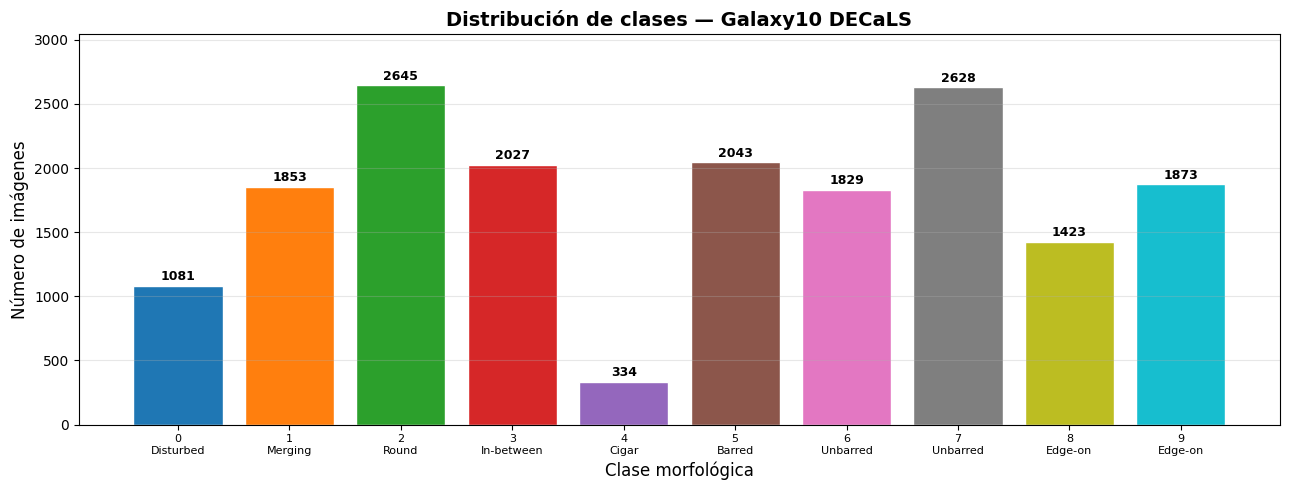

Figura guardada como 'distribucion_clases_deit.png'


In [7]:
# Distribución de clases
unique, counts = np.unique(labels, return_counts=True)

print("Distribución de clases (orden verificado experimentalmente):")
print("-" * 60)
for cls, count in zip(unique, counts):
    bar = "█" * (count // 80)
    print(f"  Clase {cls} ({CLASS_NAMES[cls][:35]:<35}): {count:5d}  {bar}")

# Gráfico de distribución
fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
bars = ax.bar(range(NUM_CLASSES), counts, color=colors, edgecolor='white')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([f"{i}\n{CLASS_NAMES[i].split()[0]}" for i in range(NUM_CLASSES)], fontsize=8)
ax.set_xlabel("Clase morfológica", fontsize=12)
ax.set_ylabel("Número de imágenes", fontsize=12)
ax.set_title("Distribución de clases — Galaxy10 DECaLS", fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("distribucion_clases_deit.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'distribucion_clases_deit.png'")

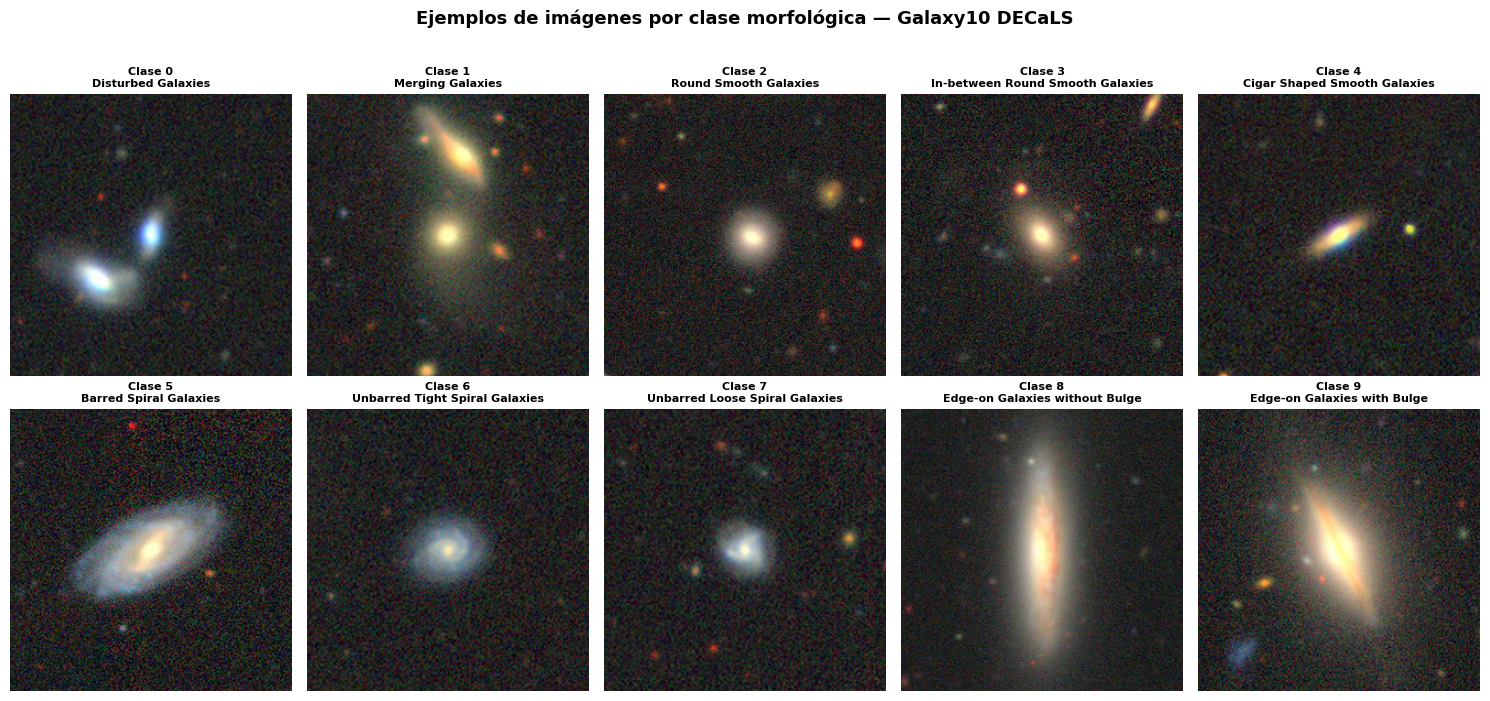

In [8]:
# Ejemplos de imágenes por clase
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for cls in range(NUM_CLASSES):
    idx = np.where(labels == cls)[0]
    random_idx = np.random.choice(idx)
    axes[cls].imshow(images[random_idx])
    axes[cls].set_title(f"Clase {cls}\n{CLASS_NAMES[cls]}", fontsize=8, fontweight='bold')
    axes[cls].axis('off')

plt.suptitle("Ejemplos de imágenes por clase morfológica — Galaxy10 DECaLS",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("ejemplos_clases_deit.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Preparación y partición de datos

In [9]:
# Partición estratificada idéntica a la usada en EfficientNetB0
# Misma semilla (42) para garantizar comparabilidad entre modelos
all_indices = np.arange(len(labels))

train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.2, stratify=labels, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=labels[temp_idx], random_state=SEED
)

print("Partición del dataset (idéntica a EfficientNetB0 para comparabilidad):")
print(f"  Entrenamiento: {len(train_idx):6d} imágenes ({len(train_idx)/len(labels)*100:.1f}%)")
print(f"  Validación:    {len(val_idx):6d} imágenes ({len(val_idx)/len(labels)*100:.1f}%)")
print(f"  Prueba:        {len(test_idx):6d} imágenes ({len(test_idx)/len(labels)*100:.1f}%)")
print(f"  Total:         {len(all_indices):6d} imágenes")

Partición del dataset (idéntica a EfficientNetB0 para comparabilidad):
  Entrenamiento:  14188 imágenes (80.0%)
  Validación:      1774 imágenes (10.0%)
  Prueba:          1774 imágenes (10.0%)
  Total:          17736 imágenes


In [10]:
# Pesos de clase para compensar el desbalanceo
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels[train_idx]),
    y=labels[train_idx]
)
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print("Pesos de clase (para compensar desbalanceo):")
for cls, weight in enumerate(class_weights):
    print(f"  Clase {cls} ({CLASS_NAMES[cls][:40]:<40}): {weight:.4f}")

Pesos de clase (para compensar desbalanceo):
  Clase 0 (Disturbed Galaxies                      ): 1.6402
  Clase 1 (Merging Galaxies                        ): 0.9574
  Clase 2 (Round Smooth Galaxies                   ): 0.6705
  Clase 3 (In-between Round Smooth Galaxies        ): 0.8747
  Clase 4 (Cigar Shaped Smooth Galaxies            ): 5.3139
  Clase 5 (Barred Spiral Galaxies                  ): 0.8683
  Clase 6 (Unbarred Tight Spiral Galaxies          ): 0.9698
  Clase 7 (Unbarred Loose Spiral Galaxies          ): 0.6750
  Clase 8 (Edge-on Galaxies without Bulge          ): 1.2457
  Clase 9 (Edge-on Galaxies with Bulge             ): 0.9471


In [11]:
# Dataset personalizado
class Galaxy10Dataset(Dataset):
    def __init__(self, images, labels, indices, transform=None):
        self.images  = images[indices]
        self.labels  = labels[indices].astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img   = Image.fromarray(self.images[idx].astype(np.uint8))
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


# DeiT-Tiny fue preentrenado con normalización ImageNet estándar
# y espera imágenes de 224x224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformaciones entrenamiento (con aumento de datos)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # útil para imágenes astronómicas
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transformaciones validación y prueba (sin aumento)
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Crear datasets y dataloaders
train_dataset = Galaxy10Dataset(images, labels, train_idx, transform=train_transform)
val_dataset   = Galaxy10Dataset(images, labels, val_idx,   transform=eval_transform)
test_dataset  = Galaxy10Dataset(images, labels, test_idx,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ DataLoaders creados")
print(f"  Batches entrenamiento: {len(train_loader)}")
print(f"  Batches validación:    {len(val_loader)}")
print(f"  Batches prueba:        {len(test_loader)}")

✅ DataLoaders creados
  Batches entrenamiento: 444
  Batches validación:    56
  Batches prueba:        56


## 5. Definición del modelo DeiT-Tiny

DeiT-Tiny (Data-efficient Image Transformer) es un transformer de visión diseñado para entrenarse eficientemente con menos datos que los ViT originales, gracias al uso de destilación del conocimiento. La variante Tiny tiene ~5.7M parámetros, siendo la más ligera de la familia DeiT.

In [12]:
def build_deit_tiny(num_classes, freeze_backbone=True):
    """
    Construye DeiT-Tiny preentrenado adaptado a num_classes.
    freeze_backbone=True:  solo entrena la cabeza clasificadora (Fase 1)
    freeze_backbone=False: entrena toda la red (Fase 2 - fine-tuning)
    """
    # Cargar DeiT-Tiny preentrenado en ImageNet desde timm
    model = timm.create_model(
        'deit_tiny_patch16_224',
        pretrained=True,
        num_classes=num_classes
    )

    # Congelar o descongelar el backbone
    for name, param in model.named_parameters():
        if 'head' in name:  # la cabeza clasificadora siempre entrena
            param.requires_grad = True
        else:
            param.requires_grad = not freeze_backbone

    return model.to(DEVICE)


# Verificar el modelo
model = build_deit_tiny(NUM_CLASSES, freeze_backbone=True)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Modelo: DeiT-Tiny (deit_tiny_patch16_224)")
print(f"  Parámetros totales:     {total_params:,}")
print(f"  Parámetros entrenables: {trainable_params:,} (Fase 1 - solo cabeza)")
print(f"  Dispositivo: {DEVICE}")
print(f"\nArquitectura resumida:")
print(f"  Patch size:   16x16 píxeles")
print(f"  Num patches:  {(IMG_SIZE//16)**2} + 2 tokens especiales (cls + distillation)")
print(f"  Embed dim:    192")
print(f"  Depth:        12 bloques transformer")
print(f"  Num heads:    3")

c:\Users\Usuario\Desktop\tfm\venv_tfm\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Usuario\.cache\huggingface\hub\models--timm--deit_tiny_patch16_224.fb_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Modelo: DeiT-Tiny (deit_tiny_patch16_224)
  Parámetros totales:     5,526,346
  Parámetros entrenables: 1,930 (Fase 1 - solo cabeza)
  Dispositivo: cuda

Arquitectura resumida:
  Patch size:   16x16 píxeles
  Num patches:  196 + 2 tokens especiales (cls + distillation)
  Embed dim:    192
  Depth:        12 bloques transformer
  Num heads:    3


## 6. Funciones de entrenamiento y evaluación

In [13]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Entrena el modelo durante una época."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, labels_batch in loader:
        imgs         = imgs.to(DEVICE)
        labels_batch = labels_batch.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1


def evaluate(model, loader, criterion):
    """Evalúa el modelo sin actualizar pesos."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels_batch in loader:
            imgs         = imgs.to(DEVICE)
            labels_batch = labels_batch.to(DEVICE)

            outputs = model(imgs)
            loss    = criterion(outputs, labels_batch)

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1, all_preds, all_labels


def train_phase(model, train_loader, val_loader, criterion, optimizer,
                n_epochs, patience, phase_name, history):
    """Ejecuta una fase completa de entrenamiento con early stopping."""
    best_val_f1      = 0.0
    patience_counter = 0
    best_model_state = None

    print(f"\n{'='*62}")
    print(f"  {phase_name}")
    print(f"{'='*62}")

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()

        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_f1, _, _ = evaluate(model, val_loader, criterion)

        elapsed = time.time() - t0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        print(f"  Época {epoch:3d}/{n_epochs} | "
              f"Train Loss: {train_loss:.4f}  F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f}  F1: {val_f1:.4f} | "
              f"Tiempo: {elapsed:.1f}s")

        if val_f1 > best_val_f1:
            best_val_f1      = val_f1
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"    ✅ Nuevo mejor modelo (Val F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  ⏹ Early stopping en época {epoch}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"  Mejor modelo restaurado (Val F1: {best_val_f1:.4f})")

    return model, history


print("✅ Funciones de entrenamiento definidas")

✅ Funciones de entrenamiento definidas


## 7. Fase 1: Entrenamiento de la cabeza clasificadora (backbone congelado)

In [14]:
# Inicializar modelo con backbone congelado
model = build_deit_tiny(NUM_CLASSES, freeze_backbone=True)

# Función de pérdida con pesos de clase
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizador solo sobre parámetros entrenables
optimizer_phase1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

# Historial de entrenamiento
history = {
    'train_loss': [], 'val_loss': [],
    'train_f1':   [], 'val_f1':   []
}

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables en Fase 1: {trainable:,}")
print("Iniciando Fase 1...\n")

# Nota: AdamW es el optimizador recomendado para transformers
# frente a Adam estándar, ya que maneja mejor el weight decay

t_start = time.time()
model, history = train_phase(
    model, train_loader, val_loader, criterion, optimizer_phase1,
    n_epochs=EPOCHS_HEAD,
    patience=PATIENCE,
    phase_name="FASE 1: Entrenamiento de la cabeza clasificadora",
    history=history
)
print(f"\nFase 1 completada en {(time.time()-t_start)/60:.1f} minutos")

Parámetros entrenables en Fase 1: 1,930
Iniciando Fase 1...


  FASE 1: Entrenamiento de la cabeza clasificadora
  Época   1/8 | Train Loss: 1.8842  F1: 0.3093 | Val Loss: 1.6782  F1: 0.3151 | Tiempo: 121.2s
    ✅ Nuevo mejor modelo (Val F1: 0.3151)
  Época   2/8 | Train Loss: 1.7016  F1: 0.3692 | Val Loss: 1.5900  F1: 0.4136 | Tiempo: 118.7s
    ✅ Nuevo mejor modelo (Val F1: 0.4136)
  Época   3/8 | Train Loss: 1.6569  F1: 0.3847 | Val Loss: 1.5432  F1: 0.4172 | Tiempo: 119.0s
    ✅ Nuevo mejor modelo (Val F1: 0.4172)
  Época   4/8 | Train Loss: 1.6267  F1: 0.3947 | Val Loss: 1.5225  F1: 0.4375 | Tiempo: 120.0s
    ✅ Nuevo mejor modelo (Val F1: 0.4375)
  Época   5/8 | Train Loss: 1.6007  F1: 0.4020 | Val Loss: 1.4876  F1: 0.4480 | Tiempo: 118.8s
    ✅ Nuevo mejor modelo (Val F1: 0.4480)
  Época   6/8 | Train Loss: 1.5995  F1: 0.4076 | Val Loss: 1.4734  F1: 0.4547 | Tiempo: 118.7s
    ✅ Nuevo mejor modelo (Val F1: 0.4547)
  Época   7/8 | Train Loss: 1.5709  F1: 0.4112 | Val Loss: 1.4798

## 8. Fase 2: Fine-tuning completo (toda la red)

In [16]:
# Descongelar todos los parámetros
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables en Fase 2: {trainable:,} (toda la red)")

# AdamW con tasa de aprendizaje reducida para fine-tuning
optimizer_phase2 = optim.AdamW(
    model.parameters(),
    lr=LR_FINETUNE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler: reduce el LR si el val_loss no mejora
# Útil para transformers que son sensibles al learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase2, mode='min', factor=0.5, patience=3
)

print("Iniciando Fase 2...\n")
t_start = time.time()
model, history = train_phase(
    model, train_loader, val_loader, criterion, optimizer_phase2,
    n_epochs=EPOCHS_FINETUNE,
    patience=PATIENCE,
    phase_name="FASE 2: Fine-tuning completo",
    history=history
)
print(f"\nFase 2 completada en {(time.time()-t_start)/60:.1f} minutos")

# Guardar modelo
torch.save(model.state_dict(), "deit_tiny_galaxy10_best.pth")
print("✅ Modelo guardado como 'deit_tiny_galaxy10_best.pth'")

Parámetros entrenables en Fase 2: 5,526,346 (toda la red)
Iniciando Fase 2...


  FASE 2: Fine-tuning completo
  Época   1/12 | Train Loss: 1.2751  F1: 0.5260 | Val Loss: 0.9911  F1: 0.6395 | Tiempo: 203.2s
    ✅ Nuevo mejor modelo (Val F1: 0.6395)
  Época   2/12 | Train Loss: 1.0166  F1: 0.6197 | Val Loss: 0.8073  F1: 0.6871 | Tiempo: 202.0s
    ✅ Nuevo mejor modelo (Val F1: 0.6871)
  Época   3/12 | Train Loss: 0.9292  F1: 0.6548 | Val Loss: 0.9131  F1: 0.6797 | Tiempo: 202.3s
  Época   4/12 | Train Loss: 0.8871  F1: 0.6631 | Val Loss: 0.6524  F1: 0.7391 | Tiempo: 200.4s
    ✅ Nuevo mejor modelo (Val F1: 0.7391)
  Época   5/12 | Train Loss: 0.8430  F1: 0.6763 | Val Loss: 0.6879  F1: 0.7352 | Tiempo: 203.6s
  Época   6/12 | Train Loss: 0.8253  F1: 0.6852 | Val Loss: 0.6878  F1: 0.7339 | Tiempo: 203.4s
  Época   7/12 | Train Loss: 0.7985  F1: 0.6988 | Val Loss: 0.6062  F1: 0.7749 | Tiempo: 195.4s
    ✅ Nuevo mejor modelo (Val F1: 0.7749)
  Época   8/12 | Train Loss: 0.7871  F1: 0.6988 |

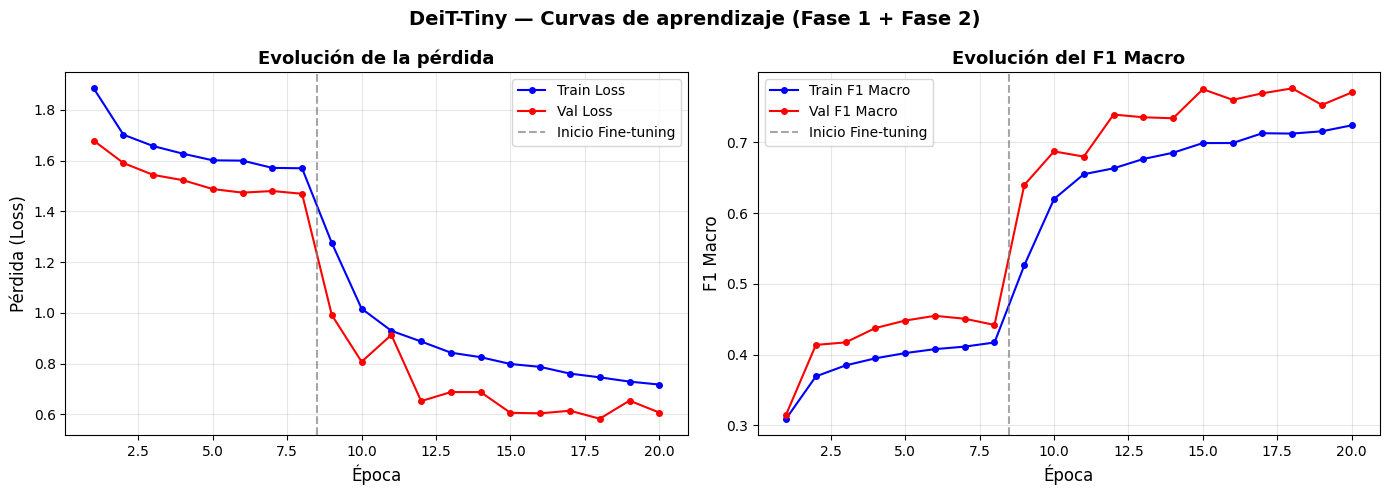

Figura guardada como 'curvas_aprendizaje_deit.png'


In [17]:
# Curvas de aprendizaje
epochs_range = range(1, len(history['train_loss']) + 1)
phase1_end   = EPOCHS_HEAD

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
axes[0].axvline(x=phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Inicio Fine-tuning')
axes[0].set_xlabel("Época", fontsize=12)
axes[0].set_ylabel("Pérdida (Loss)", fontsize=12)
axes[0].set_title("Evolución de la pérdida", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 Macro
axes[1].plot(epochs_range, history['train_f1'], 'b-o', markersize=4, label='Train F1 Macro')
axes[1].plot(epochs_range, history['val_f1'],   'r-o', markersize=4, label='Val F1 Macro')
axes[1].axvline(x=phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Inicio Fine-tuning')
axes[1].set_xlabel("Época", fontsize=12)
axes[1].set_ylabel("F1 Macro", fontsize=12)
axes[1].set_title("Evolución del F1 Macro", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("DeiT-Tiny — Curvas de aprendizaje (Fase 1 + Fase 2)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("curvas_aprendizaje_deit.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'curvas_aprendizaje_deit.png'")

## 9. Evaluación sobre el conjunto de prueba

In [18]:
# Evaluación final
print("Evaluando sobre el conjunto de prueba...")
t_eval = time.time()

test_loss, test_f1_macro, test_preds, test_labels_true = evaluate(
    model, test_loader, criterion
)

eval_time = time.time() - t_eval

# Métricas globales
accuracy  = accuracy_score(test_labels_true, test_preds)
precision = precision_score(test_labels_true, test_preds, average='macro', zero_division=0)
recall    = recall_score(test_labels_true, test_preds, average='macro', zero_division=0)
f1_macro  = f1_score(test_labels_true, test_preds, average='macro', zero_division=0)

print("\n" + "="*58)
print("  RESULTADOS FINALES — CONJUNTO DE PRUEBA")
print("  DeiT-Tiny con Fine-Tuning — Galaxy10 DECaLS")
print("="*58)
print(f"  Loss:               {test_loss:.4f}")
print(f"  Accuracy:           {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision (macro):  {precision:.4f}")
print(f"  Recall (macro):     {recall:.4f}")
print(f"  F1 Score (macro):   {f1_macro:.4f}")
print(f"  Tiempo evaluación:  {eval_time:.2f} segundos")
print("="*58)

Evaluando sobre el conjunto de prueba...

  RESULTADOS FINALES — CONJUNTO DE PRUEBA
  DeiT-Tiny con Fine-Tuning — Galaxy10 DECaLS
  Loss:               0.6139
  Accuracy:           0.7728  (77.28%)
  Precision (macro):  0.7520
  Recall (macro):     0.7836
  F1 Score (macro):   0.7516
  Tiempo evaluación:  8.55 segundos


In [19]:
# Reporte detallado por clase
print("\nREPORTE POR CLASE:")
print("-" * 80)
report = classification_report(
    test_labels_true, test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)
print(report)

# Guardar reporte
with open("classification_report_deit.txt", "w") as f:
    f.write("DeiT-Tiny con Fine-Tuning — Clasificación Morfológica de Galaxias\n")
    f.write("Galaxy10 DECaLS\n\n")
    f.write(f"Loss:              {test_loss:.4f}\n")
    f.write(f"Accuracy:          {accuracy:.4f}\n")
    f.write(f"Precision (macro): {precision:.4f}\n")
    f.write(f"Recall (macro):    {recall:.4f}\n")
    f.write(f"F1 (macro):        {f1_macro:.4f}\n")
    f.write(f"Tiempo evaluación: {eval_time:.2f}s\n\n")
    f.write(report)
print("✅ Reporte guardado en 'classification_report_deit.txt'")


REPORTE POR CLASE:
--------------------------------------------------------------------------------
                                  precision    recall  f1-score   support

              Disturbed Galaxies     0.4365    0.5093    0.4701       108
                Merging Galaxies     0.8686    0.8216    0.8444       185
           Round Smooth Galaxies     0.8356    0.9242    0.8777       264
In-between Round Smooth Galaxies     0.8485    0.8276    0.8379       203
    Cigar Shaped Smooth Galaxies     0.4776    0.9412    0.6337        34
          Barred Spiral Galaxies     0.8564    0.7561    0.8031       205
  Unbarred Tight Spiral Galaxies     0.6000    0.8689    0.7098       183
  Unbarred Loose Spiral Galaxies     0.7905    0.4449    0.5693       263
  Edge-on Galaxies without Bulge     0.9280    0.8169    0.8689       142
     Edge-on Galaxies with Bulge     0.8782    0.9251    0.9010       187

                        accuracy                         0.7728      1774
         

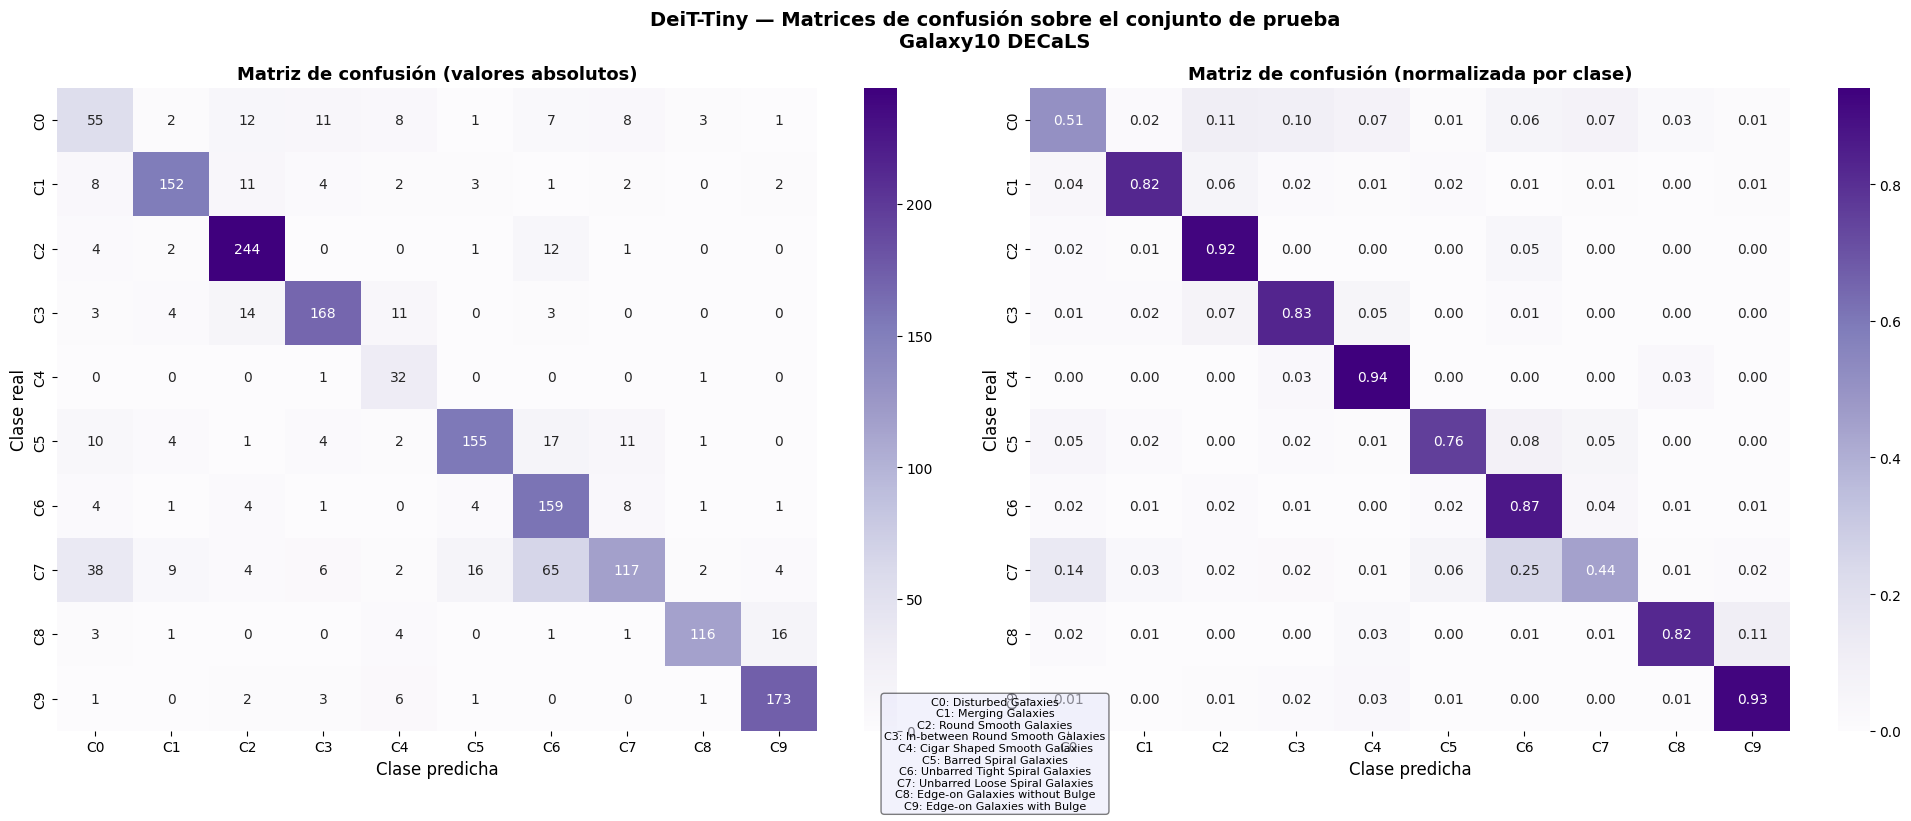

✅ Figura guardada como 'matriz_confusion_deit.png'


In [20]:
# Matrices de confusión
cm = confusion_matrix(test_labels_true, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=[f"C{i}" for i in range(NUM_CLASSES)],
            yticklabels=[f"C{i}" for i in range(NUM_CLASSES)],
            ax=axes[0])
axes[0].set_xlabel("Clase predicha", fontsize=12)
axes[0].set_ylabel("Clase real", fontsize=12)
axes[0].set_title("Matriz de confusión (valores absolutos)", fontsize=13, fontweight='bold')

# Normalizada por clase
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=[f"C{i}" for i in range(NUM_CLASSES)],
            yticklabels=[f"C{i}" for i in range(NUM_CLASSES)],
            ax=axes[1])
axes[1].set_xlabel("Clase predicha", fontsize=12)
axes[1].set_ylabel("Clase real", fontsize=12)
axes[1].set_title("Matriz de confusión (normalizada por clase)", fontsize=13, fontweight='bold')

legend_text = "\n".join([f"C{i}: {CLASS_NAMES[i]}" for i in range(NUM_CLASSES)])
fig.text(0.5, -0.02, legend_text, ha='center', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))

plt.suptitle("DeiT-Tiny — Matrices de confusión sobre el conjunto de prueba\nGalaxy10 DECaLS",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("matriz_confusion_deit.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada como 'matriz_confusion_deit.png'")

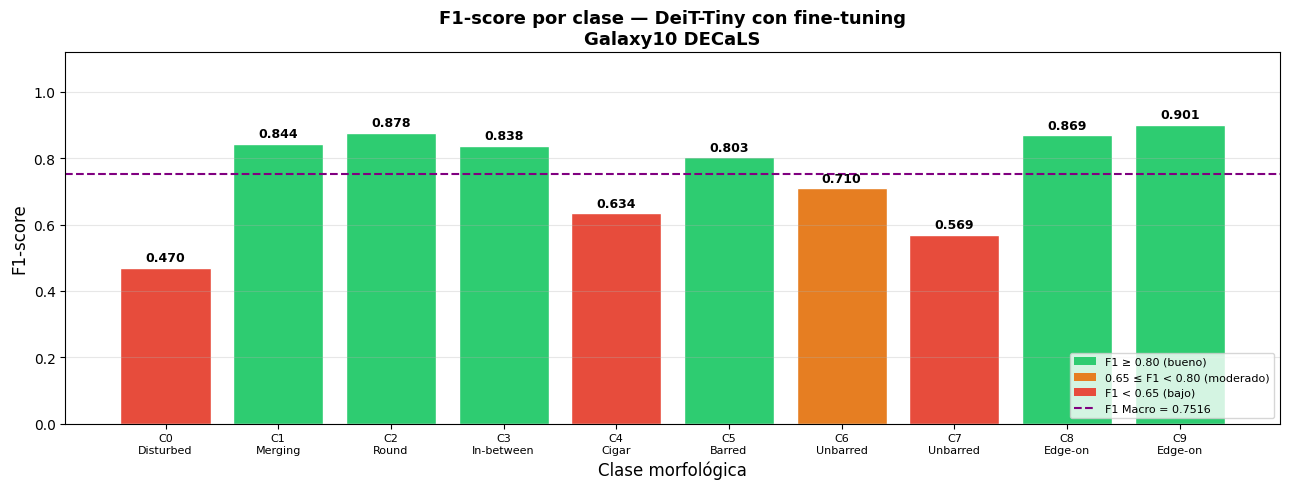

✅ Figura guardada como 'f1_por_clase_deit.png'


In [21]:
# F1-score por clase
f1_per_class = f1_score(test_labels_true, test_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#2ecc71' if f1 >= 0.80 else '#e67e22' if f1 >= 0.65 else '#e74c3c'
          for f1 in f1_per_class]
bars = ax.bar(range(NUM_CLASSES), f1_per_class, color=colors, edgecolor='white')

for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=f1_macro, color='purple', linestyle='--', linewidth=1.5,
           label=f'F1 Macro = {f1_macro:.4f}')

ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([f"C{i}\n{CLASS_NAMES[i].split()[0]}" for i in range(NUM_CLASSES)], fontsize=8)
ax.set_ylim(0, 1.12)
ax.set_xlabel("Clase morfológica", fontsize=12)
ax.set_ylabel("F1-score", fontsize=12)
ax.set_title("F1-score por clase — DeiT-Tiny con fine-tuning\nGalaxy10 DECaLS",
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='F1 ≥ 0.80 (bueno)'),
    Patch(facecolor='#e67e22', label='0.65 ≤ F1 < 0.80 (moderado)'),
    Patch(facecolor='#e74c3c', label='F1 < 0.65 (bajo)'),
    plt.Line2D([0],[0], color='purple', linestyle='--',
               linewidth=1.5, label=f'F1 Macro = {f1_macro:.4f}')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig("f1_por_clase_deit.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada como 'f1_por_clase_deit.png'")

In [22]:
# Resumen final completo
print("\n" + "="*65)
print("  RESUMEN FINAL — DeiT-Tiny con Fine-Tuning")
print("  Galaxy10 DECaLS — Clasificación Morfológica de Galaxias")
print("="*65)
print(f"\n  Configuración:")
print(f"    Arquitectura:       DeiT-Tiny (deit_tiny_patch16_224)")
print(f"    Librería:           timm")
print(f"    Tamaño de imagen:   {IMG_SIZE}×{IMG_SIZE} píxeles")
print(f"    Patch size:         16×16")
print(f"    Batch size:         {BATCH_SIZE}")
print(f"    Semilla:            {SEED}")
print(f"    Optimizador:        AdamW")
print(f"    Épocas Fase 1:      {EPOCHS_HEAD} (LR={LR_HEAD})")
print(f"    Épocas Fase 2:      {EPOCHS_FINETUNE} (LR={LR_FINETUNE})")
print(f"    Weight decay:       {WEIGHT_DECAY}")
print(f"    Dispositivo:        {DEVICE}")
print(f"\n  Métricas sobre el conjunto de prueba:")
print(f"    Loss:               {test_loss:.4f}")
print(f"    Accuracy:           {accuracy:.4f}")
print(f"    Precision (macro):  {precision:.4f}")
print(f"    Recall (macro):     {recall:.4f}")
print(f"    F1 Macro:           {f1_macro:.4f}")
print(f"    Tiempo evaluación:  {eval_time:.2f}s")
print(f"\n  F1-score por clase:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, f1_per_class)):
    print(f"    C{i} {name:<45}: {f1:.4f}")
print("="*65)


  RESUMEN FINAL — DeiT-Tiny con Fine-Tuning
  Galaxy10 DECaLS — Clasificación Morfológica de Galaxias

  Configuración:
    Arquitectura:       DeiT-Tiny (deit_tiny_patch16_224)
    Librería:           timm
    Tamaño de imagen:   224×224 píxeles
    Patch size:         16×16
    Batch size:         32
    Semilla:            42
    Optimizador:        AdamW
    Épocas Fase 1:      8 (LR=0.001)
    Épocas Fase 2:      12 (LR=0.0001)
    Weight decay:       0.0001
    Dispositivo:        cuda

  Métricas sobre el conjunto de prueba:
    Loss:               0.6139
    Accuracy:           0.7728
    Precision (macro):  0.7520
    Recall (macro):     0.7836
    F1 Macro:           0.7516
    Tiempo evaluación:  8.55s

  F1-score por clase:
    C0 Disturbed Galaxies                           : 0.4701
    C1 Merging Galaxies                             : 0.8444
    C2 Round Smooth Galaxies                        : 0.8777
    C3 In-between Round Smooth Galaxies             : 0.8379
    C4 Ci

---
## Archivos generados

| Archivo | Descripción |
|---|---|
| `deit_tiny_galaxy10_best.pth` | Pesos del mejor modelo entrenado |
| `classification_report_deit.txt` | Métricas detalladas por clase |
| `distribucion_clases_deit.png` | Distribución del dataset |
| `ejemplos_clases_deit.png` | Ejemplos visuales por clase |
| `curvas_aprendizaje_deit.png` | Evolución de loss y F1 |
| `matriz_confusion_deit.png` | Matrices de confusión |
| `f1_por_clase_deit.png` | F1-score por clase morfológica |

Estas figuras y métricas son las que necesitas para redactar los apartados **5.5** y **6.4** de la memoria del TFM.